<img src="./logo_UTN.svg" align="right" width="150" /> 

# Informe TP Lab

*Alumnos: Lapilli Cañedo, Mariano Adrian y Olea Gasalla, Ignacio Ezequiel*

In [7]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti

## Consigna

<img src="./plantillas.png" width="800" />


### Análisis y Simulacion ( Pre-Lab )

1. Obtener el orden del filtro y hallar la función transferencia total. 

2. Obtener la transferencia de la red circuital a implementar. 

3. Simulación numérica/simbólica de la función transferencia en Python. 

4. Simulación circuital. Incluya el modelo real del OPAMP.

### Implementacion y armado ( Pre-Lab )

1. Disenar el Layout del PCB.

2. Usar conectores, headers o borneras para alimentar el filtro, introducir la señal de entrada, medir la señal de entrada y salida ( test points )  

3. Utilizar un zócalo DIP 14 para colocar el OPAMP y DIP 16 para el OTA.

4. Incluir resistores variables ( presets / trimmer ) o bien resistores fijos con tolerancias del 1%.

5. Agregar capacitores de bypass en la alimentacion del Amplificador. Agregar capacitor electrolítico o poliéster de 1 µF a 100 µF con otro cerámico de 100 nF a 470 nF en paralelo para reducir el ruido de la fuente.

### Medicion ( In-Lab )

1. Verificar visualmente y con el multímetro que el circuito no tiene cortocircuitos y que los componentes estén correctamente soldados. 

2. Utilice la limitación de corriente de la fuente en algunas decenas de mA. Para ello se debe poner en corto los bornes de + y - a una tensión baja por ejemplo 1 V. De esta manera el equipo entra en modo CC ( corto circuito ) y se puede setear el nivel de corriente. 

3. Setear la tensión de la fuente. Utilice un multímetro para ajustar la tensión de la fuente. Finalmente alimente su circuito.  Tenga en cuenta que la medición mejora para niveles más altos de fuente.

4. Verifique las puntas del osciloscopio. Utilice la señal de prueba tanto en el canal 1 como 2 para ajustar la respuesta temporal visualizada. Verifique el valor de AC y periodo de esta señal de prueba con los medidores del DSO.

5. Calibre una señal senoidal en el generador a un nivel que optimice la medición en la banda de paso de  valor medio nulo con el generador. Tenga en cuenta que el filtro puede generar sobretensiones a la salida.

6. Desenergice el circuito si así estuviera y conecte el integrado. Conecte la alimentación nuevamente y el generador de entrada. Verifique que el DSO tenga señal a la salida. Debe ser de la misma forma ( sin distorsión ) que la entrada con una cierta fase y alguna diferencia de amplitud probablemente.

7. Llegado a este punto está en condiciones de realizar un barrido con frecuencia :D

## Resolución

Se eligió el filtro Notch y se sintetizará mediante la topología **Twin T**

<img src="./filtro.png" width="1000" />

Vamos a hallar analiticamente la transferencia de este filtro:

La misma esta definida como: 

$$T(s) = \frac{s^2 + \frac{1}{T^2}}{s^2 + \frac{4}{T(1+K)} s +\frac{1}{T^2}}$$

Donde:

$T = \frac{1}{RC}$

$K = \frac{R_0}{R_1}$

$Q_0 = \frac{1 + K}{4}$

Sabiendo esto, vamos a seleccionar los componentes:

Vamos a utilizar un capacitor $10\mu F$, por lo que:

$$ \omega_o = \frac{1}{\sqrt{RC}} \rightarrow R = 330 \Omega$$

Con el dato del ancho de banda de $10Hz$:

$$Q = \frac{1+K}{4} =\frac{50Hz}{10Hz} = 5 \rightarrow K = \frac{R_0}{R1} = 19 \rightarrow R_0 = 19 \ \ R_1$$

Elegimos $R_1 = 560\Omega$ y $R_0 = 10k\Omega$; de este modo obtenemos un $Q$ de 4,71.

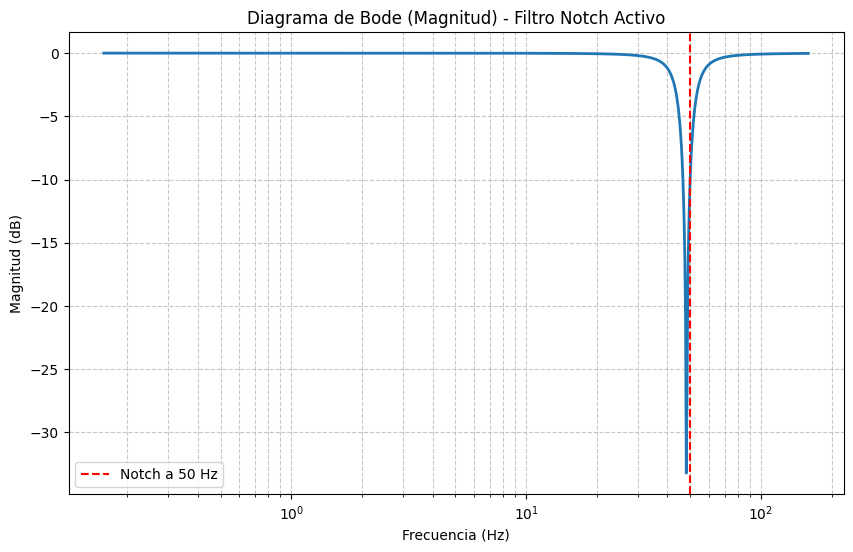

In [8]:
# Simulo filtro

C = 10e-6
R = 330
R0 = 10e3
R1 = 560
w0 = 1 / (R * C)
k = R0 / R1

num = [1, 0, w0**2]

den = [1, (4 * w0) / (1+k), w0**2]

H = sig.TransferFunction(num, den)

w, mag, phase = sig.bode(H, w=np.logspace(0, 3, 1000))
f = w / (2 * np.pi)

plt.figure(figsize=(10, 6))
plt.semilogx(f, mag, linewidth=2)

plt.axvline(x=50, color='red', linestyle='--', label=f'Notch a 50 Hz')

plt.title('Diagrama de Bode (Magnitud) - Filtro Notch Activo')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend()

plt.show()

Como simulación circuital utilizamos un operacional genérico al no poder importar el LM324 a LTSpice:

<img src="./simucirc.png" width="1000" />

<img src="./simu.png" width="1000" />


## Laboratorio

Una vez en el laboratorio, se hicieron medidas tomando distintos puntos, 20 puntos en concreto y obtuvuimos como resultado:


<img src="./resultados.png" width="500" />

Una vez obtenidos estos resultados, se procedió a realizar un ensayo en el analizador de audio, de los cuales sacamos los siguientes resultados.

Se graficarán por medio de Python:

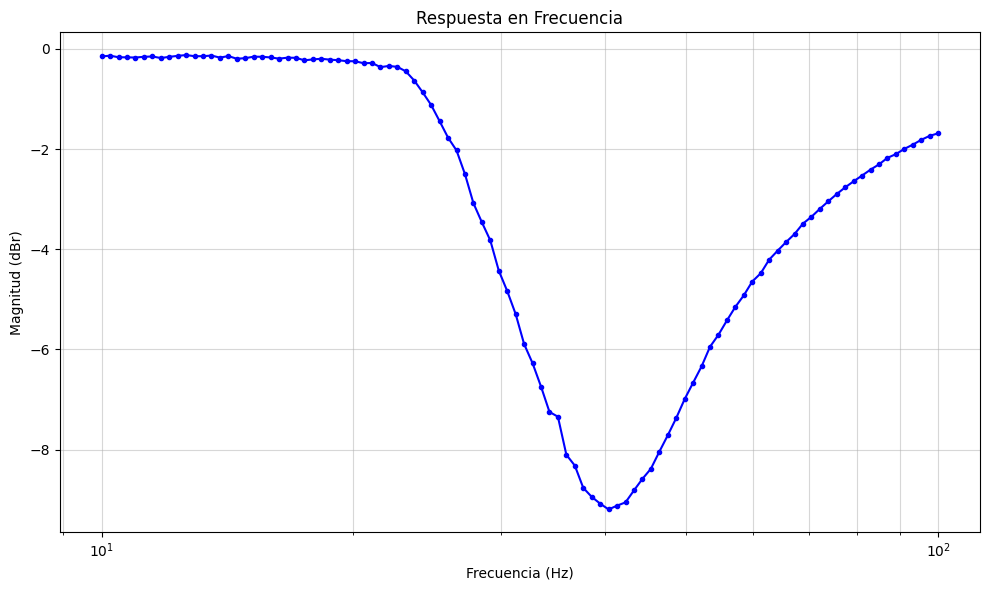

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('modulo.csv', skiprows=2, names=['Frequency (Hz)', 'Magnitude (dBr)'])

df['Frequency (Hz)'] = pd.to_numeric(df['Frequency (Hz)'], errors='coerce')
df['Magnitude (dBr)'] = pd.to_numeric(df['Magnitude (dBr)'], errors='coerce')

df = df.dropna()

plt.figure(figsize=(10, 6))

plt.semilogx(df['Frequency (Hz)'], df['Magnitude (dBr)'], marker='.', linestyle='-', color='b')

plt.title('Respuesta en Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dBr)')

plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

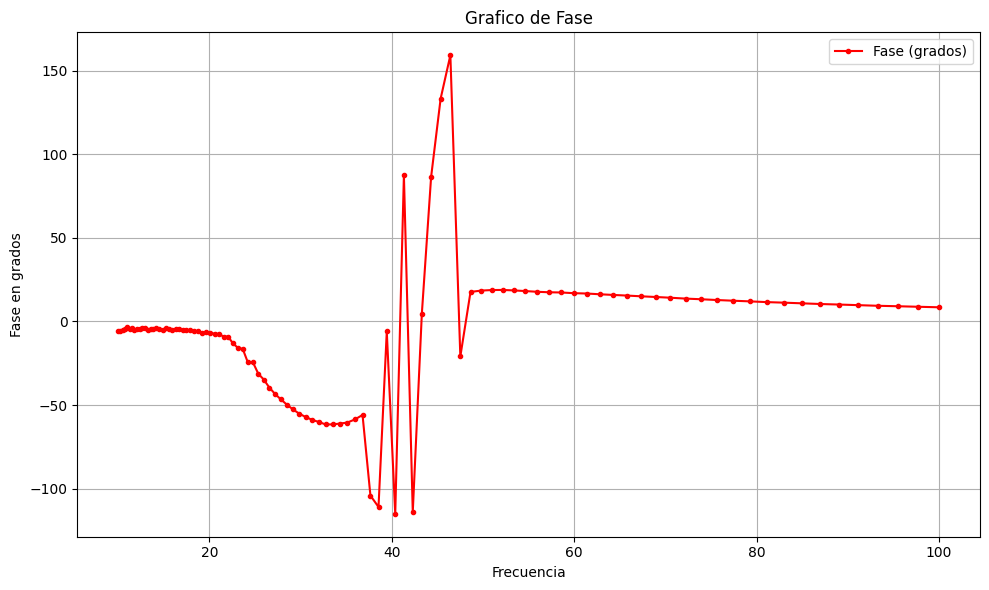

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("fase.csv", skiprows=2)

df.columns = df.columns.str.strip()

df['X (Hz)'] = pd.to_numeric(df['X (Hz)'], errors='coerce')
df['Ch-1'] = pd.to_numeric(df['Ch-1'], errors='coerce')

df = df.dropna()

plt.figure(figsize=(10, 6))
plt.plot(df['X (Hz)'], df['Ch-1'], label='Fase (grados)', color='red', marker='.', linestyle='-')

plt.title('Grafico de Fase')
plt.xlabel('Frecuencia')
plt.ylabel('Fase en grados')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Conclusiones: Como se pueden observar en ambos gráficos, estos no satisfacen al completo lo esperado en la simulación, esto puede deberse a dispersión en los valores de los componentes (principalmente porque depende en mayor parte de los capacitores y pequeñas variaciones en estos componentes pueden ocasionar variaciones) o al hecho de que estamos utilizando solo dos operacionales a diferencia de otras topologías mas robustas como puede ser la Ackerber-Mossberg. Concretamente en el gráfico de la fase se puede detectar que la misma sufre un glitch en la zona crítica, esto creemos que puede deberse a la cantidad de puntos que decidimos gráficar en el analizador de audio. 